# Tutorial: Reveal Dynamics of Time-Dependent Observables with a Multi-Exponential Fit

This tutorial presents and explains the relevant steps to perform a stable timescale analysis, unraveling the important dynamics of several observables.
The multi-exponential fit provides non-zero amplitdues that indicate position and strength of distinct processes.

## Preparation

The data files are stored in a single folder, and each column is treated as a separate observable (e.g., distance between $C_\alpha$-atoms).

In this example we study 3 observables for which we exactly know the expected timescales:
- Observable 1: 1e1, 1e3
- Observable 2: 7e0, 2e3
- Observable 3: 8e0, 1e2, 1.5e3

Three trajectories are generated to function as simulated data.

In a first step (Preprocessing) the data files are loaded, averaged and stored to be used in the actual analysis.
This sequence must be executed only a single time! Afterwards, the .json file with the preprocessed data should be used, which contains: **mean**, **standard error of the mean** and **labels** for each observables, as well as the corresponding **time** of each frame.

Additionally, one can provide the class a simulation file that defines the time step value, and a label file providing labels for each observable.

In [3]:
import timescaleanalysis

preP = timescaleanalysis.Preprocessing(
    './Tutorial_multiExpFunction_run'
)
# Get all files in path that match the prefix
preP.generate_input_trajectories()
preP.load_trajectories()
preP.get_time_array()
preP.save_preprocessed_data(
    output_path='./Tutorial_output_files/'
)

Tutorial_multiExpFunction_run1.txt
Tutorial_multiExpFunction_run2.txt
Tutorial_multiExpFunction_run3.txt
No simulation parameters provided, generate time array.
Saving preprocessed data to ./Tutorial_output_files//preprocessed_data.json


## Timescale analysis

With the preprocessing a single time performed, the averaged observables are loaded from the .json file and preparations for the analysis are performed. The log-spacing allows for an (approximately) equal weight of each order of magnitude.

In [4]:
tsa = timescaleanalysis.TimeScaleAnalysis(preP.data_dir, 4)
tsa.load_data()
# It is recommended to target at least around 100 data points per decade
tsa.log_space_data(5000)

Next, we loop over each observable, perform the timescale analysis and display the results. **Thats all the magic needed!**

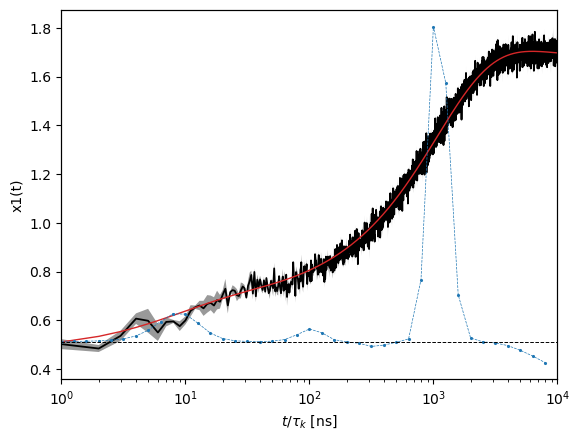

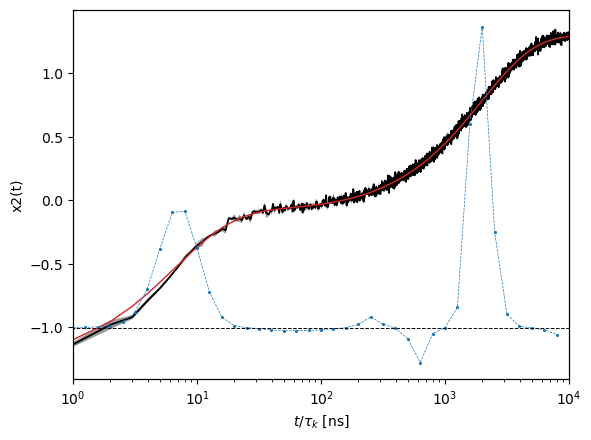

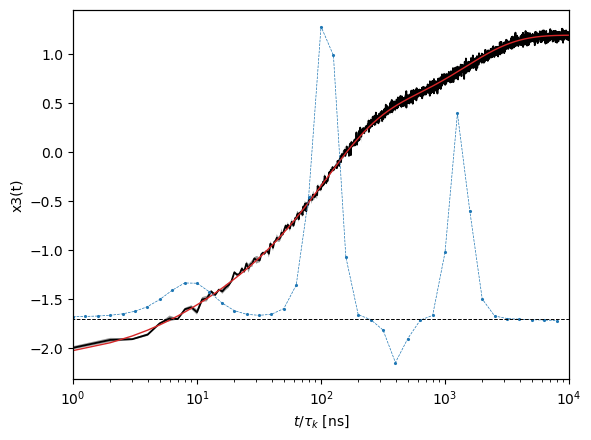

In [5]:
import timescaleanalysis.plotting as plotting
import matplotlib.pyplot as plt

for idxObs in range(tsa.data_mean.shape[1]):
    tsa.options['temp_mean'] = tsa.data_mean[:, idxObs]
    tsa.options['temp_sem'] = tsa.data_sem[:, idxObs]
    temp_label = tsa.labels[idxObs]

    regPara = 200  # controls over/under fitting
    tsa.perform_tsa(
        regPara=regPara,
        startTime=1e0,
    )
    ax1, _ = plotting.plot_TSA(
        tsa.data_mean[:, idxObs],
        tsa.data_sem[:, idxObs],
        tsa.spectrum,
        tsa.times
    )
    ax1.set_xlim(1e0, 1e4)
    ax1.set_xlabel(r'$t/\tau_k$ [ns]')
    ax1.set_ylabel(f'{plotting.pretty_label(temp_label, prefix='')}(t)')
    plt.show()

The spectram can be saved using `io.save_npArray` which is especially handy when you want to change the plotting style, combine several spectra without rerunning the analysis or perform subsequent analyses.

## Improvements of the analysis

There are a few recommended adjustments that should be applied to the averaged data set prior to the `tsa.perform_tsa` step.

### Gaussian filter
The first and most commonly used one is applying a Gaussian filter to the data. This decreases fast fluctuations that are simply a result of background noise (such as thermal noise). Typically, the filter is applyied after all preparations are finished, however, it can also be applied earlier in the analysis if desired.

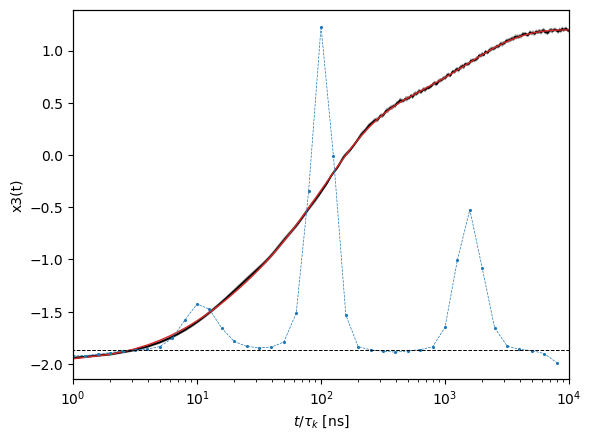

In [6]:
import timescaleanalysis.utils as utils

# For simplicity, we only look at the 3rd observable
temp_mean = utils.gaussian_smooth(tsa.data_mean[:, 2], sigma=6)
temp_sem = utils.gaussian_smooth(tsa.data_sem[:, 2], sigma=6)
tsa.options['temp_mean'] = temp_mean
tsa.options['temp_sem'] = temp_sem
temp_label = tsa.labels[2]

regPara = 50  # requires adjustments
tsa.perform_tsa(
    regPara=regPara,
    startTime=1e0,
)
ax1, _ = plotting.plot_TSA(
    temp_mean,
    temp_sem,
    tsa.spectrum,
    tsa.times
)
ax1.set_xlim(1e0, 1e4)
ax1.set_xlabel(r'$t/\tau_k$ [ns]')
ax1.set_ylabel(f'{plotting.pretty_label(temp_label, prefix='')}(t)')
plt.show()

### Interpolation and extension
Most often, one has a lot fewer frames in the initial decades than in the later ones. While the log-spacing already improves this by removing many frames, there are simply to few frames in the beginning to actually achive log-spacing.

In order to obtain an **accurate description of the fast dynamics**, it is recommended to apply an interpolation of additional frames in between existing frames. This has little to no influence on slow timescales but significantly improves the resolution at the lower boundary.

In [7]:
tsa_best = timescaleanalysis.TimeScaleAnalysis(preP.data_dir, 5)
tsa_best.load_data()
# `iterations=2`: interpolation is applied twice
# Therfore, the number of frames are quadrupled
tsa_best.interpolate_data_points(iterations=2)
tsa_best.log_space_data(5000)

In other cases (and especially in molecular dynamics simulation) it is not possible to simulate long enough that the system fully reaches an equilibrium state. This is a known problem throughout all analytical methods of MD, and here, results in unstable timescales at the upper boundary. To ensure a good convergence we recommend to extend the time trace by one order of magnitude by a constant value.

Important: if you study data that is still strongly changing at the upper boundary, this will resolve the problem!

In [8]:
tsa_best.extend_timeTrace(frac_decade=7/10)

Now, we redo the analysis together with Gaussian filtering and obtain a nice and stable result!

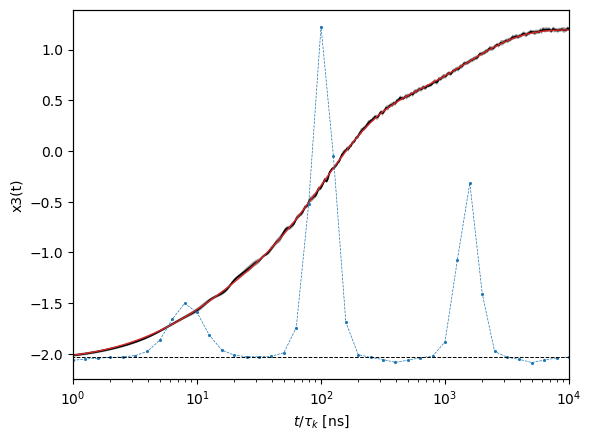

In [9]:
# For simplicity, we only look at the 3rd observable
temp_mean = utils.gaussian_smooth(tsa_best.data_mean[:, 2], sigma=6)
temp_sem = utils.gaussian_smooth(tsa_best.data_sem[:, 2], sigma=6)
tsa_best.options['temp_mean'] = temp_mean
tsa_best.options['temp_sem'] = temp_sem
temp_label = tsa_best.labels[2]

regPara = 100  # requires adjustments
tsa_best.perform_tsa(
    regPara=regPara,
    startTime=1e0,
)
ax1, _ = plotting.plot_TSA(
    temp_mean,
    temp_sem,
    tsa_best.spectrum,
    tsa_best.times
)
ax1.set_xlim(1e0, 1e4)
ax1.set_xlabel(r'$t/\tau_k$ [ns]')
ax1.set_ylabel(f'{plotting.pretty_label(temp_label, prefix='')}(t)')
plt.show()

## Optimal Regularization Parameter

The above optimizations are very helpful, however, when the regularization parameter `regPara` is badly chosen, this will not still not produce satisfying results.
By scanning through several values for `regPara` and using the Bayesian posterior probability, one can rather quickly find an 'optimal' one that balances precision while preventing overfitting.

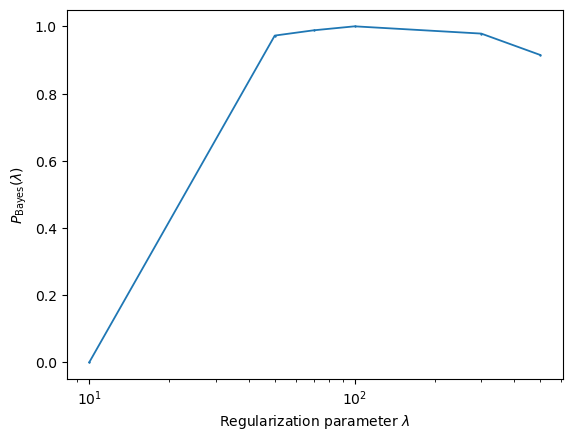

In [10]:
scanned_regPara = [10, 50, 70, 100, 300, 500, 1000]
P_Bayes = timescaleanalysis.timescales.derive_optimal_regularization(
    tsa_best,
    idxObs=2,
    regPara=scanned_regPara,
    startTime=1e0,
    sigma=6,
)
plt.plot(scanned_regPara, P_Bayes, marker='+', ms=2.0, lw=1.3)
plt.xscale('symlog', subs=[2,3,4,5,6,7,8,9], linthresh=1e-2)
plt.xlabel(r'Regularization parameter $\lambda$')
plt.ylabel(r'$P_{\mathrm{Bayes}}(\lambda)$')
plt.show()